# Example 1: Symbolic Regressor

In [1]:
import sys
import math
from pathlib import Path

from pyparsing import results

# Add the parent folder (my_project) to Python's search path
sys.path.append(str(Path.cwd().parent))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from collections import defaultdict
import ipywidgets as widgets
from IPython.display import HTML, display
from joblib import dump, load
from enum import StrEnum
from collections import defaultdict



In [2]:
def get_feature_map(function_set, n_features):
    """Creates a dictionary mapping every function name and feature index to a vector slot."""
    feature_map = {}
    idx = 0

    # 1. Map all function names (e.g., 'add', 'sub', 'mul')
    for func in function_set:
        feature_map[func.name] = idx
        idx += 1

    # 2. Map all feature indices (0, 1, 2, ... n_features - 1)
    for feat_idx in range(n_features):
        feature_map[feat_idx] = idx
        idx += 1

    # 3. Map Constant Bins
    constant_bins = [
        'CONST_Q0_To_Q1',  # c < min + 0.25 * range
        'CONST_Q1_To_Q2',  # min + 0.25 * range <= c < min + 0.50 * range
        'CONST_Q2_To_Q3',  # min + 0.50 * range A<= c < min + 0.75 * range
        'CONST_Q3_To_Q4'   # c >= min + 0.75 * range
    ]

    for bin_name in constant_bins:
        feature_map[bin_name] = idx
        idx += 1

    return feature_map

In [3]:
class MetricKey(StrEnum):
    # Metadata
    seed = 'Seed'
    benchmark = 'Benchmark'
    r2_score = 'R2_Score'
    formula = 'Formula'
    program_vector = 'Program Vector'
    parameter = 'Parameter'
    prediction = 'Prediction'
    test_dataset = 'Test Dataset'
    spearman_score = 'Spearman Correlation'

    # Performance
    prey_fitness = 'Prey Fitness'
    parent_avg_parsimony_fit = 'Parent Avg Parsimony Fitness'
    parent_avg_final_fit = 'Parent Avg Final Fitness'

    # Prey Metrics
    prey_avg_length = 'Prey Average Length'
    prey_avg_fitness = 'Prey Average Fitness'
    prey_best_fitness = 'Prey Best Fitness'
    prey_best_length = 'Prey Best Length'
    prey_div_distance = 'Prey Diversity Distance'
    prey_div_entropy = 'Prey Diversity Entropy'
    prey_entropy_prob = 'Prey Entropy Probability'
    prey_entropy_hist = 'Prey Entropy History'

    # Predator Metrics
    pred_avg_length = 'Predator Average Length'
    pred_avg_fitness = 'Predator Average Fitness'
    pred_best_fitness = 'Predator Best Fitness'
    pred_best_length = 'Predator Best Length'
    pred_div_distance = 'Predator Diversity Distance'
    pred_div_entropy = 'Predator Diversity Entropy'
    pred_entropy_prob = 'Predator Entropy Probability'
    pred_entropy_hist = 'Predator Entropy History'

    # Miscellaneous
    feature_map = 'Feature Map'
    penalty_values = 'Penalty Values'

In [4]:
# Load the exact object back into memory
results = load('temp.joblib')
print(f"Loaded {len(results)} records successfully.")

Loaded 4 records successfully.


In [5]:
def plot_r2_histogram(results= results):
    # Convert results into a DataFrame
    df_results = pd.DataFrame(results)

    # Display summary table with mean and standard deviation across seeds
    df_summary = df_results.groupby('Benchmark')['R2_Score'].agg(['mean', 'std']).reset_index()
    # print("\n--- Summary Performance across seeds ---")
    # print(df_summary)

    # Plot Bar Chart comparison across benchmarks with error bars (representing variability across seeds)
    plt.figure(figsize=(15, 5))
    sns.barplot(
        data=df_results,
        x='Benchmark',
        y='R2_Score',
        hue='Benchmark',
        palette='mako',
        errorbar='sd',       # Shows standard deviation across seeds
        capsize=0.1,         # Adds caps to error bars
        legend=False,
        edgecolor='black'
    )

    # Overlay individual seed points
    sns.stripplot(
        data=df_results,
        x='Benchmark',
        y='R2_Score',
        color='white',
        alpha=0.6,
        jitter=0.2,
        size=5
    )

    plt.axhline(0, color='red', linestyle='--', label='Baseline R^2 = 0.0')
    plt.ylim(top=1.05)
    plt.title('Test R2 Score Across Benchmarks (Mean +- SD over Random Seeds)', fontsize=12, fontweight='bold')
    plt.ylabel('R2 Score (Higher is Better)')
    plt.grid(axis='y', linestyle=':', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [6]:
# Plot Fitness of Prey VS Predator

def plot_fitness(line_alpha = 0.75):

    # 1. Group records by benchmark name directly from results
    benchmark_groups = defaultdict(list)
    for record in results:
        benchmark_groups[record["Benchmark"]].append(record)

    # 2. Set up subplots dynamically based on benchmark count
    n_benchmarks = len(benchmark_groups)
    fig, axes = plt.subplots(
        n_benchmarks, 2, figsize=(12, 5 * n_benchmarks), squeeze=False
    )

    # 3. Iterate through grouped data
    for row_idx, (b_name, records) in enumerate(benchmark_groups.items()):
        ax_r2 = axes[row_idx, 0]
        ax_prd_fitness = axes[row_idx, 1]

        for record in records:
            seed = record["Seed"]
            prey_fitness = record[MetricKey.prey_fitness]
            predator_fitness = record["Predator Best Fitness"]

            # Plot Prey R2 Score on Left Subplot
            ax_r2.plot(
                range(len(prey_fitness)),
                prey_fitness,
                linewidth=1.5,
                label=f"Seed {seed}",
                alpha= line_alpha,
            )

            # Plot Predator Fitness on Right Subplot
            ax_prd_fitness.plot(
                range(len(predator_fitness)),
                predator_fitness,
                linewidth=1.5,
                label=f"Seed {seed}",
                alpha= line_alpha,
            )

        # Formatting Left (Prey R2 Score)
        ax_r2.set_title(
            f"{b_name} $R^2$ Score Progress", fontsize=11, fontweight="bold"
        )
        ax_r2.set_xlabel("Generation")
        ax_r2.set_ylabel("$R^2$ Score")
        ax_r2.set_ylim(-1, 1.05)
        ax_r2.grid(True, linestyle="--", alpha=0.6)
        ax_r2.legend(loc="lower right")

        # Formatting Right (Predator Fitness)
        ax_prd_fitness.set_title(
            f"{b_name} Predator Best Fitness", fontsize=11, fontweight="bold"
        )
        ax_prd_fitness.set_xlabel("Generation")
        ax_prd_fitness.set_ylabel("Predator Best Fitness")
        ax_prd_fitness.set_ylim(bottom=0)
        ax_prd_fitness.grid(True, linestyle="--", alpha=0.6)
        ax_prd_fitness.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

In [7]:
def plot(
    results,
    benchmark_list=None,
    seed_list=None,
    data1=MetricKey.prey_fitness,
    data2=MetricKey.prey_avg_fitness,
    data1_range=None,
    data2_range=None,
    line_alpha=0.75,
    is_legend=True,
):
    """Plots two metrics side-by-side for each benchmark, with individual lines for each seed.

    Filters results by benchmark_list and seed_list if provided.
    """
    # 1. Filter and group records: { benchmark_name: [records...] }
    benchmark_groups = defaultdict(list)
    for record in results:
        bm_match = (
            benchmark_list is None
            or record["Benchmark"] in benchmark_list
        )
        seed_match = (
            seed_list is None or record["Seed"] in seed_list
        )

        if bm_match and seed_match:
            benchmark_groups[record["Benchmark"]].append(record)

    if not benchmark_groups:
        print("No matching records found for the given benchmarks and seeds.")
        return

    # 2. Set up subplots dynamically (1 row per benchmark, 2 columns for data1 & data2)
    n_benchmarks = len(benchmark_groups)
    fig, axes = plt.subplots(
        n_benchmarks, 2, figsize=(12, 4.5 * n_benchmarks), squeeze=False
    )

    # 3. Plot records grouped by benchmark
    for row_idx, (b_name, records) in enumerate(benchmark_groups.items()):
        ax_left = axes[row_idx, 0]
        ax_right = axes[row_idx, 1]

        # Sort records by seed for consistent legend ordering
        records_sorted = sorted(records, key=lambda x: x["Seed"])

        for record in records_sorted:
            seed = record["Seed"]
            y_data1 = record[data1]
            y_data2 = record[data2]

            # Left plot (Metric 1)
            ax_left.plot(
                range(len(y_data1)),
                y_data1,
                linewidth=1.5,
                label=f"Seed {seed}",
                alpha=line_alpha,
            )

            # Right plot (Metric 2)
            ax_right.plot(
                range(len(y_data2)),
                y_data2,
                linewidth=1.5,
                label=f"Seed {seed}",
                alpha=line_alpha,
            )

        # Format Left Subplot
        ax_left.set_title(f"{b_name} - {data1}", fontsize=11, fontweight="bold")
        ax_left.set_xlabel("Generation")
        ax_left.set_ylabel(str(data1))
        if data1_range is not None:
            ax_left.set_ylim(data1_range)
        ax_left.grid(True, linestyle="--", alpha=0.6)

        # Format Right Subplot
        ax_right.set_title(
            f"{b_name} - {data2}", fontsize=11, fontweight="bold"
        )
        ax_right.set_xlabel("Generation")
        ax_right.set_ylabel(str(data2))
        if data2_range is not None:
            ax_right.set_ylim(data2_range)
        ax_right.grid(True, linestyle="--", alpha=0.6)

        if is_legend:
            ax_left.legend(loc="lower right", fontsize="small")
            ax_right.legend(loc="lower right", fontsize="small")

    plt.tight_layout()
    plt.show()

In [8]:
def plot_metrics_per_seed(
    results,
    benchmark_list=None,
    seed_list=None,
    data1=MetricKey.prey_avg_length,
    data2=MetricKey.prey_best_length,
    data1_label=None,
    data2_label=None,
    y_range=None,
    line_alpha=0.75,
    x_label = "Generation",
    y_label = "Value",
    is_legend=True,
):
    """Plots a grid of graphs where each graph represents ONE (benchmark, seed) pair,

    displaying both required metrics (data1 and data2) together on the same axes.
    """
    # 1. Filter and organize records: { benchmark_name: { seed: record } }
    grouped_data = defaultdict(dict)
    all_found_seeds = set()

    for record in results:
        bm = record["Benchmark"]
        seed = record["Seed"]

        bm_match = benchmark_list is None or bm in benchmark_list
        seed_match = seed_list is None or seed in seed_list

        if bm_match and seed_match:
            grouped_data[bm][seed] = record
            all_found_seeds.add(seed)

    if not grouped_data:
        print("No matching records found for the specified benchmarks and seeds.")
        return

    sorted_benchmarks = sorted(grouped_data.keys())
    sorted_seeds = sorted(list(all_found_seeds))

    n_rows = len(sorted_benchmarks)
    n_cols = len(sorted_seeds)

    # 2. Set up grid layout (1 row per benchmark, 1 column per seed)
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.5 * n_cols, 4.0 * n_rows),
        squeeze=False,
        sharex=True,
    )

    # 3. Iterate over benchmarks (rows) and seeds (columns)
    for row_idx, bm in enumerate(sorted_benchmarks):
        for col_idx, seed in enumerate(sorted_seeds):
            ax = axes[row_idx, col_idx]
            record = grouped_data[bm].get(seed)

            if record is not None:
                y1 = record[data1]
                y2 = record[data2]
                gens = range(len(y1))

                # Plot metric 1
                ax.plot(
                    gens,
                    y1,
                    linewidth=1.5,
                    label=data1_label if data1_label is not None else data1,
                    alpha=line_alpha,
                    color="#1f77b4",  # Blue
                )

                # Plot metric 2
                ax.plot(
                    gens,
                    y2,
                    linewidth=1.5,
                    label=data2_label if data2_label is not None else data2,
                    alpha=line_alpha,
                    color="#ff7f0e",  # Orange
                )

                ax.set_title(f"{bm} (Seed {seed})", fontsize=10, fontweight="bold")
                ax.set_xlabel(f"{x_label}")
                ax.set_ylabel(f"{y_label}")

                if y_range is not None:
                    ax.set_ylim(y_range)

                ax.grid(True, linestyle="--", alpha=0.6)

                if is_legend:
                    ax.legend(loc="upper right", fontsize="small")
            else:
                # Handle missing (benchmark, seed) pairs cleanly
                ax.axis("off")

    plt.tight_layout()
    plt.show()

In [9]:
# Plot Distance Diversity of Prey VS Predator

def plot_diversity_distance(line_alpha = 0.75):

    # 1. Group records by benchmark name directly from results
    benchmark_groups = defaultdict(list)
    for record in results:
        benchmark_groups[record["Benchmark"]].append(record)

    # 2. Set up subplots dynamically based on benchmark count
    n_benchmarks = len(benchmark_groups)
    fig, axes = plt.subplots(n_benchmarks, 2, figsize=(12, 6 * n_benchmarks), squeeze=False)

    for row_idx, (b_name, records) in enumerate(benchmark_groups.items()):
        ax_prey_dist = axes[row_idx, 0]
        ax_prd_dist = axes[row_idx, 1]

        for record in records:
            seed = record["Seed"]
            prey_dist = record["Prey Diversity Distance"]
            prd_dist = record["Predator Diversity Distance"]

            # Plot Diversity
            ax_prey_dist.plot(range(len(prey_dist)), prey_dist, linewidth=1.5, label=f'Seed {seed}', alpha= line_alpha)
            ax_prd_dist.plot(range(len(prd_dist)), prd_dist, linewidth=1.5, label=f'Seed {seed}', alpha= line_alpha)

        # Formatting Left
        ax_prey_dist.set_title(f'{b_name} Prey Diversity (Distances)', fontsize=11, fontweight='bold')
        ax_prey_dist.set_xlabel('Generation')
        ax_prey_dist.set_ylabel('Prey Diversity (Distances)')
        ax_prey_dist.set_ylim(0, 1.05)
        ax_prey_dist.grid(True, linestyle='--', alpha=0.6)

        # Formatting Right
        ax_prd_dist.set_title(f'{b_name} Predator Diversity (Distances)', fontsize=11, fontweight='bold')
        ax_prd_dist.set_xlabel('Generation')
        ax_prd_dist.set_ylabel('Predator Diversity (Distances)')
        ax_prd_dist.set_ylim(0, 1.05)
        ax_prd_dist.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [10]:
# Plot Entropy Diversity of Prey VS Predator

def plot_diversity_entropy(line_alpha = 0.75):

    # 1. Group records by benchmark name directly from results
    benchmark_groups = defaultdict(list)
    for record in results:
        benchmark_groups[record["Benchmark"]].append(record)

    # 2. Set up subplots dynamically based on benchmark count
    n_benchmarks = len(benchmark_groups)
    fig, axes = plt.subplots(n_benchmarks, 2, figsize=(12, 6 * n_benchmarks), squeeze=False)

    for row_idx, (b_name, records) in enumerate(benchmark_groups.items()):
        ax_prey_dist = axes[row_idx, 0]
        ax_prd_dist = axes[row_idx, 1]

        for record in records:
            seed = record["Seed"]
            prey_dist = record["Prey Diversity Entropy"]
            prd_dist = record["Predator Diversity Entropy"]

            # Plot Diversity
            ax_prey_dist.plot(range(len(prey_dist)), prey_dist, linewidth=1.5, label=f'Seed {seed}', alpha= line_alpha)
            ax_prd_dist.plot(range(len(prd_dist)), prd_dist, linewidth=1.5, label=f'Seed {seed}', alpha= line_alpha)

        # Formatting Left
        ax_prey_dist.set_title(f'{b_name} Prey Diversity (Entropy)', fontsize=11, fontweight='bold')
        ax_prey_dist.set_xlabel('Generation')
        ax_prey_dist.set_ylabel('Prey Diversity (Entropy)')
        ax_prey_dist.set_ylim(0, 1.05)
        ax_prey_dist.grid(True, linestyle='--', alpha=0.6)

        # Formatting Right
        ax_prd_dist.set_title(f'{b_name} Predator Diversity (Entropy)', fontsize=11, fontweight='bold')
        ax_prd_dist.set_xlabel('Generation')
        ax_prd_dist.set_ylabel('Predator Diversity (Entropy)')
        ax_prd_dist.set_ylim(0, 1.05)
        ax_prd_dist.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [11]:
# Plot Prey Multiple Data

def plot_solution_data(line_alpha = 0.75):

    # 1. Group records by benchmark name directly from results
    benchmark_groups = defaultdict(list)
    for record in results:
        benchmark_groups[record["Benchmark"]].append(record)

    # 2. Set up subplots dynamically based on benchmark count
    n_benchmarks = len(benchmark_groups)
    fig, axes = plt.subplots(n_benchmarks, 3, figsize=(18, 6 * n_benchmarks), squeeze=False)

    for row_idx, (b_name, records) in enumerate(benchmark_groups.items()):
        ax_r2 = axes[row_idx, 0]
        ax_prey_diver_distance = axes[row_idx, 1]
        ax_prey_diver_entropy = axes[row_idx, 2]

        for record in records:
            seed = record["Seed"]
            prey_fitness = record[MetricKey.prey_fitness]
            prey_diversity_distance = record[MetricKey.prey_div_distance]
            prey_diversity_entropy = record[MetricKey.prey_avg_length]

            # Plot Prey R2 Score on Left Subplot
            ax_r2.plot(
                range(len(prey_fitness)),
                prey_fitness,
                linewidth=1.5,
                label=f"Seed {seed}",
                alpha= line_alpha,
            )

            ax_prey_diver_distance.plot(
                range(len(prey_diversity_distance)),
                prey_diversity_distance,
                linewidth=1.5,
                label=f'Seed {seed}',
                alpha= line_alpha
            )

            ax_prey_diver_entropy.plot(
                range(len(prey_diversity_entropy)),
                prey_diversity_entropy,
                linewidth=1.5,
                label=f'Seed {seed}',
                alpha= line_alpha
            )

        # Formatting Left (Prey R2 Score)
        ax_r2.set_title(
            f"{b_name} $R^2$ Score Progress", fontsize=11, fontweight="bold"
        )
        ax_r2.set_xlabel("Generation")
        ax_r2.set_ylabel("$R^2$ Score")
        ax_r2.set_ylim(-1, 1.05)
        ax_r2.grid(True, linestyle="--", alpha=0.6)
        ax_r2.legend(loc="lower right")

        # Formatting Middle (Prey Diversity Distance)
        ax_prey_diver_distance.set_title(f'{b_name} Prey Diversity (Distance)', fontsize=11, fontweight='bold')
        ax_prey_diver_distance.set_xlabel('Generation')
        ax_prey_diver_distance.set_ylabel('Prey Diversity (Distance)')
        ax_prey_diver_distance.set_ylim(0, 1.05)
        ax_prey_diver_distance.grid(True, linestyle='--', alpha=0.6)

        # Formatting Left
        ax_prey_diver_entropy.set_title(f'{b_name} - {MetricKey.prey_avg_length}', fontsize=11, fontweight='bold')
        ax_prey_diver_entropy.set_xlabel('Generation')
        ax_prey_diver_entropy.set_ylabel(f"{MetricKey.prey_avg_length}")
        ax_prey_diver_entropy.set_ylim(bottom=0)
        ax_prey_diver_entropy.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [12]:
def plot_entropy_heatmaps(line_alpha = 0.75):
    """Plots side-by-side entropy heatmaps (Prey vs Predator) using the feature

    map stored inside each record in results.
    """
    for res in results:
        seed = res['Seed']
        name = res['Benchmark']
        r2 = res['R2_Score']

        # Extract feature map directly from this record
        feature_map = res['Feature Map']

        # Build Y-axis labels sorted by column index
        labels = [None] * len(feature_map)
        for key, idx in feature_map.items():
            labels[idx] = str(key)

        prey_history = np.array(res['Prey Entropy History'])
        pred_history = np.array(res['Predator Entropy History'])

        if prey_history.size == 0 or pred_history.size == 0:
            print(f'Skipping {name} (Seed {seed}): Empty entropy history.')
            continue

        fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

        # 1. Prey Heatmap
        sns.heatmap(
            prey_history.T,
            ax=axes[0],
            cmap='viridis',
            yticklabels=labels,
            cbar_kws={'label': 'Shannon Entropy (bits)'},
            vmin=0.0,
        )
        axes[0].set_title(
            f'Prey Locus Entropy\n(Seed: {seed} | Benchmark: {name})',
            fontsize=12,
        )
        axes[0].set_xlabel('Generation', fontsize=10)
        axes[0].set_ylabel('Feature / Locus', fontsize=10)

        # 2. Predator Heatmap
        sns.heatmap(
            pred_history.T,
            ax=axes[1],
            cmap='plasma',
            yticklabels=labels,
            cbar_kws={'label': 'Shannon Entropy (bits)'},
            vmin=0.0,
        )
        axes[1].set_title(
            f'Predator Locus Entropy\n(Test R2: {r2:.4f})', fontsize=12
        )
        axes[1].set_xlabel('Generation', fontsize=10)

        # Adjust X-ticks readability
        n_gens = prey_history.shape[0]
        step = max(1, n_gens // 10)
        for ax in axes:
            ax.set_xticks(np.arange(0, n_gens, step))
            ax.set_xticklabels(np.arange(0, n_gens, step), rotation=0)

        plt.suptitle(
            f'Co-Evolutionary Structural Diversity Heatmap - {name}',
            fontsize=14,
            fontweight='bold',
        )
        plt.tight_layout()
        plt.show()

In [13]:
def plot_entropy_heatmaps_tabs(line_alpha=0.75, plot_datatype ='R2 Score Per Generation', heatmap_datatype ='Prey Entropy History'):
    """Creates a tabbed session interface where each Benchmark has its own tab containing all its seed plots."""
    benchmarks = list(dict.fromkeys(res['Benchmark'] for res in results))
    tab = widgets.Tab()
    tab_outputs = []

    for b_name in benchmarks:
        out = widgets.Output()
        benchmark_results = [
            res for res in results if res['Benchmark'] == b_name
        ]

        with out:
            for res in benchmark_results:
                seed = res['Seed']
                name = res['Benchmark']
                plot_dataset = res[plot_datatype]
                feature_map = res['Feature Map']

                labels = [None] * len(feature_map)
                for key, idx in feature_map.items():
                    labels[idx] = str(key)

                heatmap_dataset = np.array(res[heatmap_datatype])

                if heatmap_dataset.size == 0:
                    continue

                fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

                # Left: R2 Plot
                axes[0].plot(
                    range(len(plot_dataset)),
                    plot_dataset,
                    linewidth=1.5,
                    color='tab:orange',
                    label=f'Seed {seed}',
                    alpha=line_alpha,
                )
                axes[0].set_title(
                    f'{plot_datatype} (Seed {seed})',
                    fontsize=11,
                    fontweight='bold',
                )
                axes[0].set_xlabel('Generation')
                axes[0].set_ylabel(f'{plot_datatype}')
                # axes[0].set_ylim(-1.0, 1.05)
                axes[0].grid(True, linestyle='--', alpha=0.6)

                # Right: Heatmap
                sns.heatmap(
                    heatmap_dataset.T,
                    ax=axes[1],
                    cmap='viridis',
                    yticklabels=labels,
                    cbar_kws={'label': f'{heatmap_datatype}'},
                    vmin=0.0,
                    # vmax=0.5,
                )
                axes[1].set_title(
                    f'Locus Entropy (Seed {seed})', fontsize=11
                )
                axes[1].set_xlabel('Generation')

                n_gens = len(plot_dataset)
                step = max(1, n_gens // 10)
                x_ticks = np.arange(0, n_gens, step)
                axes[0].set_xticks(x_ticks)
                axes[1].set_xticks(x_ticks + 0.5)
                axes[1].set_xticklabels(x_ticks, rotation=0)

                plt.tight_layout()
                plt.show()

        tab_outputs.append(out)

    tab.children = tab_outputs
    for i, name in enumerate(benchmarks):
        tab.set_title(i, f'Benchmark: {name}')

    display(tab)


# Usage:
# plot_experiment_entropy_heatmaps_tabs(results)

In [14]:
def plot_entropy_heatmaps_tabs_double(
    results = results,
    left_datatype='Predator Entropy History',
    right_datatype='Prey Entropy History',
):
    """Creates a tabbed interface plotting two side-by-side locus entropy heatmaps for each seed."""
    benchmarks = list(dict.fromkeys(res['Benchmark'] for res in results))
    tab = widgets.Tab()
    tab_outputs = []

    for b_name in benchmarks:
        out = widgets.Output()
        benchmark_results = [
            res for res in results if res['Benchmark'] == b_name
        ]

        with out:
            for res in benchmark_results:
                seed = res['Seed']
                name = res['Benchmark']
                feature_map = res['Feature Map']

                # 1. Load both dataset matrices
                left_dataset = np.array(res[left_datatype])
                right_dataset = np.array(res[right_datatype])

                if left_dataset.size == 0 or right_dataset.size == 0:
                    continue

                # 2. Extract feature labels in order
                labels = [None] * len(feature_map)
                for key, idx in feature_map.items():
                    labels[idx] = str(key)

                # 3. Create 1x2 subplot canvas
                fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

                # Left Heatmap
                sns.heatmap(
                    left_dataset.T,
                    ax=axes[0],
                    cmap='viridis',
                    yticklabels=labels,
                    cbar_kws={'label': f'{left_datatype} (Seed {seed})'},
                    vmin=0.0,
                )
                axes[0].set_title(
                    f'{left_datatype} (Seed {seed})',
                    fontsize=11,
                    fontweight='bold',
                )
                axes[0].set_xlabel('Generation')

                # Right Heatmap
                sns.heatmap(
                    right_dataset.T,
                    ax=axes[1],
                    cmap='viridis',
                    yticklabels=labels,
                    cbar_kws={'label': f'{right_datatype}'},
                    vmin=0.0,
                )
                axes[1].set_title(
                    f'{right_datatype} (Seed {seed})',
                    fontsize=11,
                    fontweight='bold',
                )
                axes[1].set_xlabel('Generation')

                # 4. Configure X-axis tick intervals
                n_gens = left_dataset.shape[0]
                step = max(1, n_gens // 10)
                x_ticks = np.arange(0, n_gens, step)

                for ax in axes:
                    ax.set_xticks(x_ticks + 0.5)
                    ax.set_xticklabels(x_ticks, rotation=0)

                plt.tight_layout()
                plt.show()

        tab_outputs.append(out)

    tab.children = tab_outputs
    for i, name in enumerate(benchmarks):
        tab.set_title(i, f'{name}')

    display(tab)

In [15]:
def plot_prediction_histogram(
    results,
    benchmark_list=None,
    seed=None,
    bins=50,
    alpha=0.7,
):
    """Plots separate side-by-side histograms for Ground Truth (Left) vs Model Predictions (Right)

    for each benchmark/seed run.
    """
    if not results:
        print("Error: 'results' is empty or None.")
        return

    # 1. Filter records based on seed and benchmark_list
    filtered_records = []
    for r in results:
        if not isinstance(r, dict):
            continue
        bm_match = (
            benchmark_list is None
            or r.get(MetricKey.benchmark) in benchmark_list
        )
        seed_match = seed is None or r.get(MetricKey.seed) == seed
        if bm_match and seed_match:
            filtered_records.append(r)

    if not filtered_records:
        print("No matching records found in results.")
        return

    # 2. Setup subplot grid: 1 row per record, 2 columns (Left: True, Right: Pred)
    n_records = len(filtered_records)
    fig, axes = plt.subplots(
        n_records, 2, figsize=(11, 4 * n_records), squeeze=False
    )

    # 3. Plot each record in its own row
    for row_idx, record in enumerate(filtered_records):
        ax_true = axes[row_idx, 0]  # Left: Ground Truth
        ax_pred = axes[row_idx, 1]  # Right: Model Prediction

        b_name = record[MetricKey.benchmark]
        r_seed = record[MetricKey.seed]
        y_true = record[MetricKey.test_dataset]
        y_pred = record[MetricKey.prediction]
        r2 = record[MetricKey.r2_score]

        # Calculate common x-axis limits so both subplots share the exact same scale
        min_val = min(np.min(y_true), np.min(y_pred))
        max_val = max(np.max(y_true), np.max(y_pred))

        # --- Left Plot: Ground Truth ---
        sns.histplot(
            y_true,
            bins=bins,
            kde=True,
            ax=ax_true,
            color="skyblue",
            edgecolor="navy",
            alpha=alpha,
        )
        ax_true.set_title(
            f"{b_name} (Seed {r_seed}) — Ground Truth\nMean: {np.mean(y_true):.2f} | Std: {np.std(y_true):.2f}",
            fontsize=10,
            fontweight="bold",
        )
        ax_true.set_xlabel("Target Response (y)")
        ax_true.set_ylabel("Count")
        ax_true.set_xlim(min_val, max_val)
        ax_true.grid(True, linestyle="--", alpha=0.5)

        # --- Right Plot: Predictions ---
        sns.histplot(
            y_pred,
            bins=bins,
            kde=True,
            ax=ax_pred,
            color="coral",
            edgecolor="darkred",
            alpha=alpha,
        )
        ax_pred.set_title(
            f"{b_name} (Seed {r_seed}) — Predictions (R²: {r2:.4f})\nMean: {np.mean(y_pred):.2f} | Std: {np.std(y_pred):.2f}",
            fontsize=10,
            fontweight="bold",
        )
        ax_pred.set_xlabel("Predicted Response (y_pred)")
        ax_pred.set_ylabel("Count")
        ax_pred.set_xlim(min_val, max_val)
        ax_pred.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

In [16]:
def plot_program_weight_histogram(vec, feature_map, title="Node Weight Distribution"):
    """Plots a bar chart of node weights for a single program vector."""
    # Reverse feature_map to map index -> label
    index_to_label = {idx: str(key) for key, idx in feature_map.items()}

    labels = [index_to_label[i] for i in range(len(vec))]
    weights = vec

    plt.figure(figsize=(10, 4))
    bars = plt.bar(
        labels, weights, color="steelblue", edgecolor="black", alpha=0.85
    )

    plt.title(title, fontsize=12, fontweight="bold")
    plt.xlabel("Primitives / Features", fontsize=10)
    plt.ylabel("Weighted Count ($2^{-depth}$)", fontsize=10)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.6)

    # Annotate non-zero bars with exact weight values
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(
                bar.get_x() + bar.get_width() / 2.0,
                height,
                f"{height:.2f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    plt.tight_layout()
    plt.show()

In [17]:
for key, value in results[0]['Parameter'].items():
    print(f"{key:30}: {value}")

catch_num                     : 4
catch_penalty                 : 0.25
catch_size                    : 20
const_range                   : (-5, 5)
data_record_diversity_distance: True
data_record_diversity_entropy : True
elites_type                   : raw fitness
feature_names                 : ('x1', 'x2', 'x3', 'x4', 'x5')
function_set                  : ('add', 'sub', 'mul', 'div', 'sin', 'cos', 'tan')
generations                   : 50
init_depth                    : (2, 6)
init_method                   : half and half
low_memory                    : False
max_samples                   : 1.0
metric                        : temp
n_jobs                        : 1
p_crossover                   : 0.7
p_hoist_mutation              : 0.05
p_point_mutation              : 0.1
p_point_replace               : 0.05
p_subtree_mutation            : 0.1
parsimony_coefficient         : 0.005
population_size               : 100
predator_competitive_consts   : 1.0
predator_n_elites             : 1


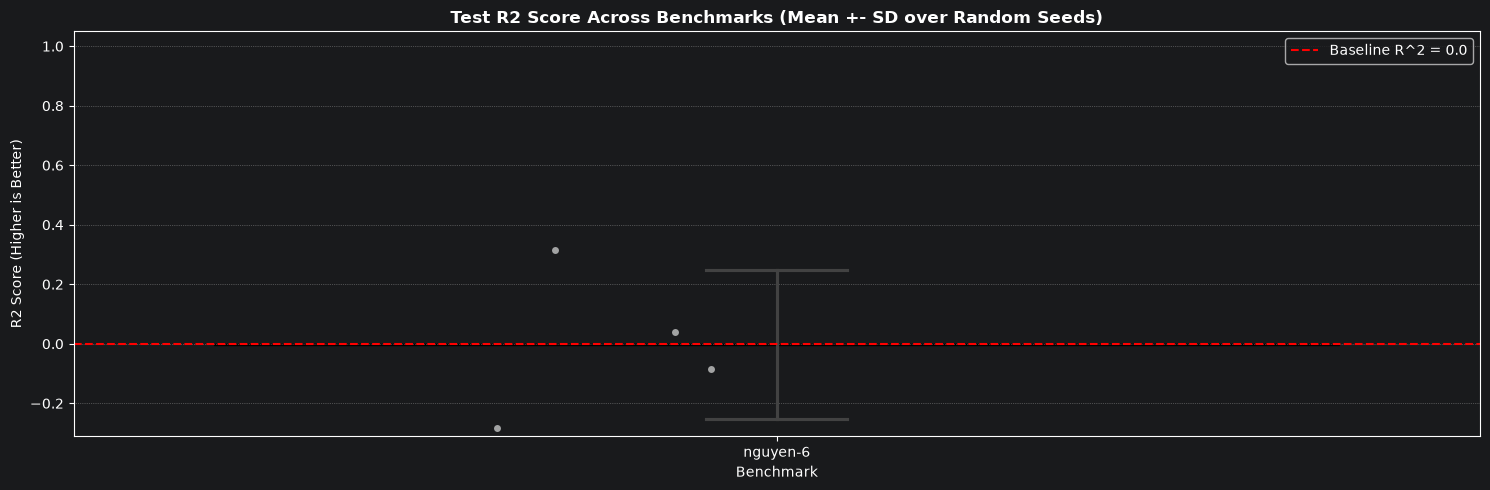

In [18]:
plot_r2_histogram()

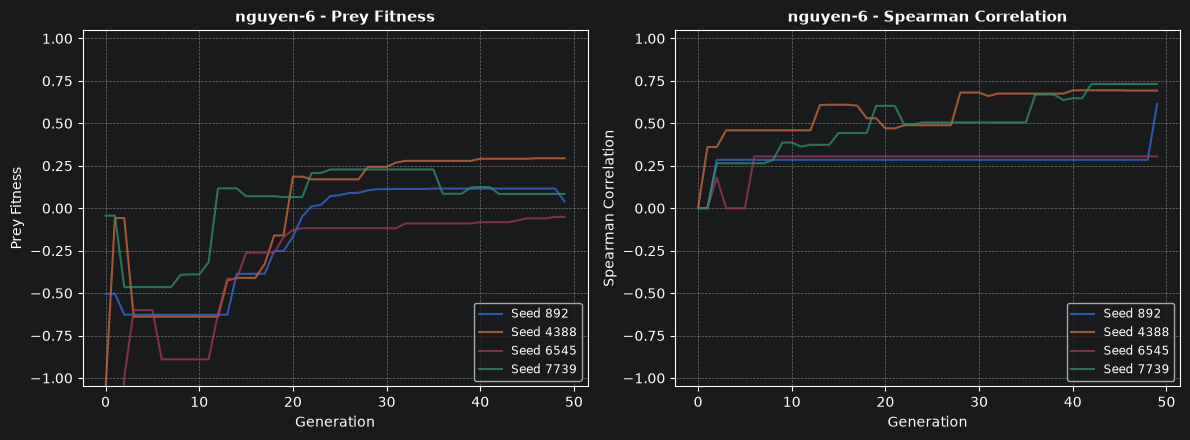

In [19]:
plot(data1=MetricKey.prey_fitness, data2=MetricKey.spearman_score, results= results, data1_range=(-1.05, 1.05), data2_range=(-1.05, 1.05))

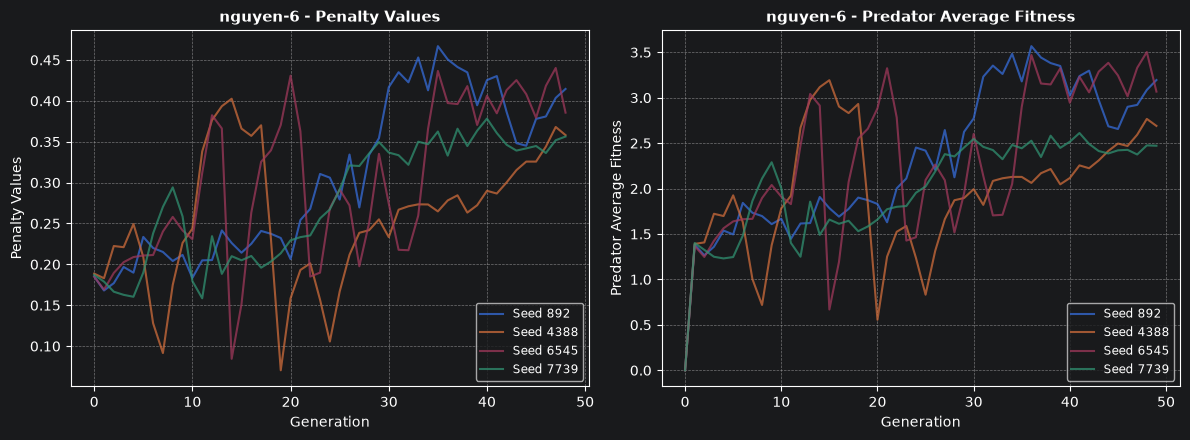

In [20]:
plot(results=results, data1=MetricKey.penalty_values, data2=MetricKey.pred_avg_fitness)

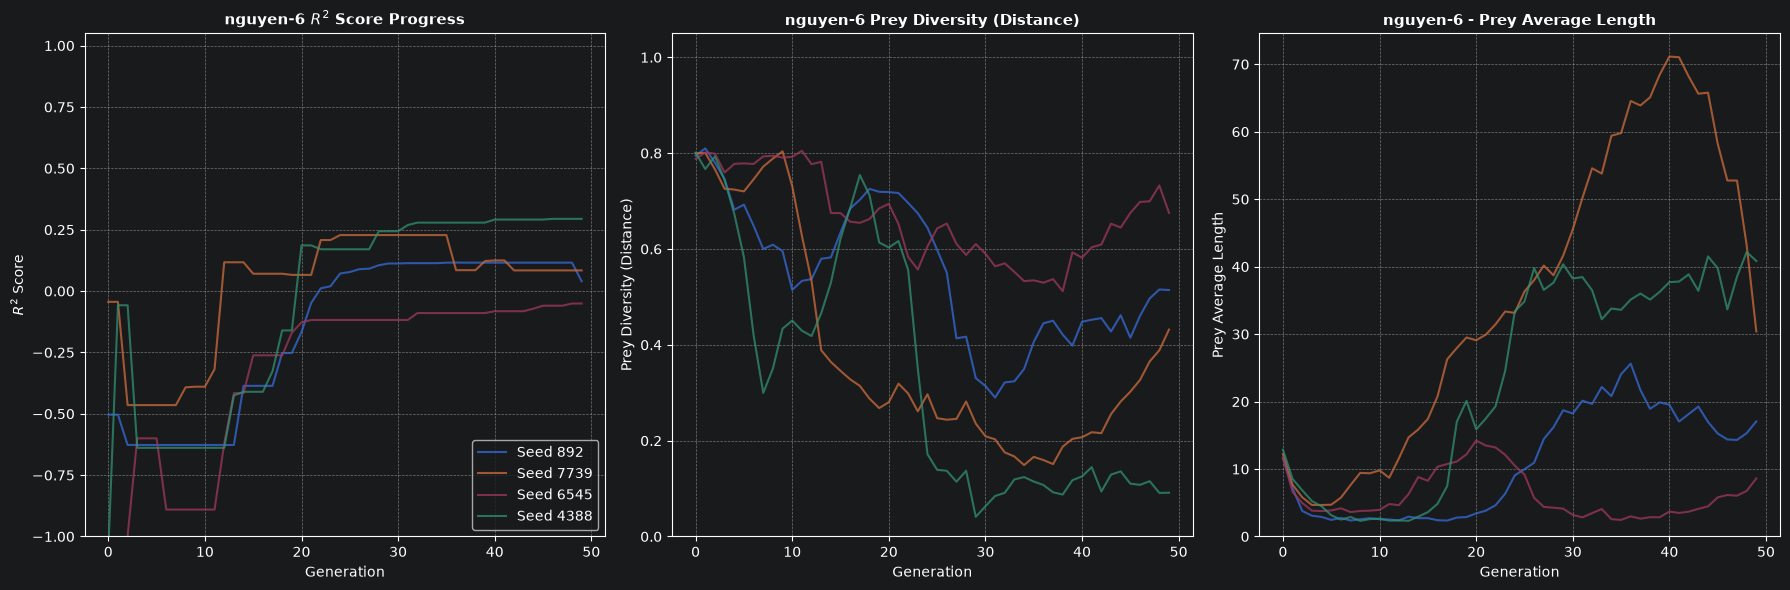

In [21]:
plot_solution_data()

In [22]:
plot_entropy_heatmaps_tabs_double(results=results, left_datatype=MetricKey.prey_entropy_prob, right_datatype=MetricKey.pred_entropy_prob)

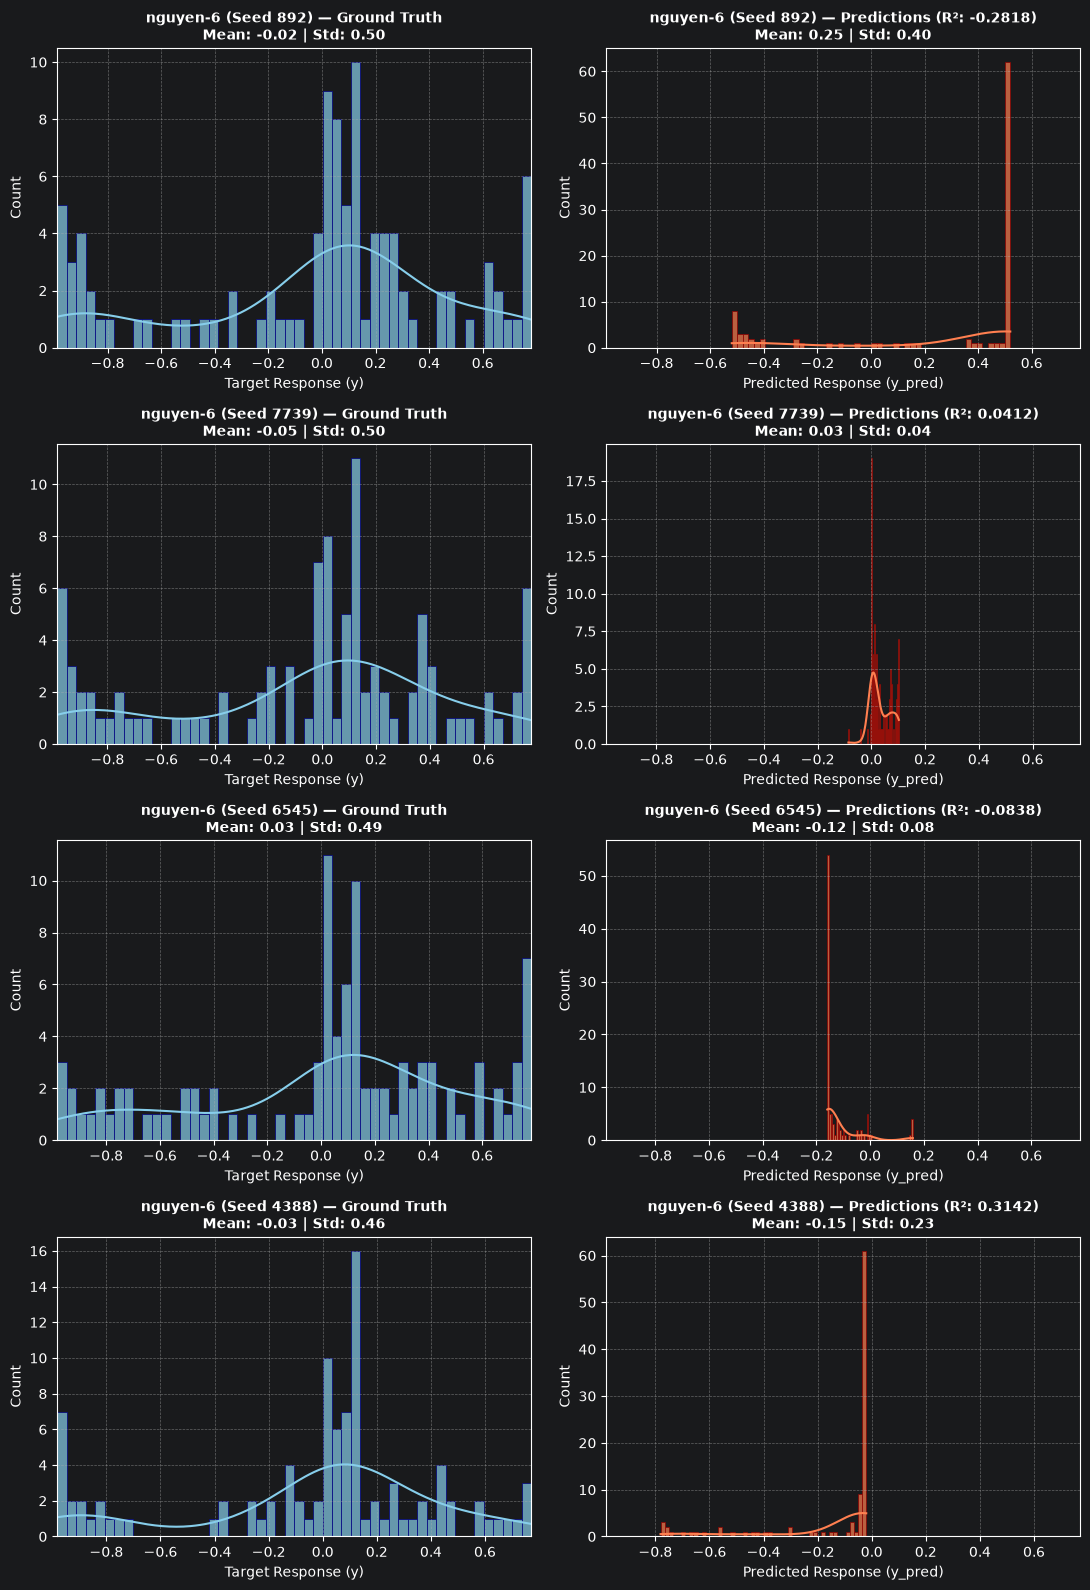

In [23]:
plot_prediction_histogram(results=results)